# CIFAR-10 Dataset Exploration and Analysis

**Module:** CN-7023 Artificial Intelligence & Machine Vision  
**Institution:** University of East London

---

## Objectives

1. Load and explore the CIFAR-10 dataset
2. Understand dataset structure and characteristics
3. Visualize sample images from each class
4. Analyze class distribution
5. Examine image statistics (mean, std, pixel distributions)
6. Identify potential challenges for classification

---

In [ ]:
# === SETUP: Handle paths for both local and Colab ===
import os
import pathlib

# Auto-detect environment and set paths
if 'google.colab' in str(get_ipython()):
    print("[COLAB] Running in Google Colab")
    # In Colab, ensure we're in the right location
    if not os.path.exists('/content/UEL-ai-assignment'):
        %cd /content
        !git clone https://github.com/sebastien15/UEL-ai-assignment.git
    %cd /content/UEL-ai-assignment
    BASE_PATH = '/content/UEL-ai-assignment'
else:
    print("[LOCAL] Running locally")
    # Local environment
    BASE_PATH = '.'

# Set up paths
DATA_PATH = os.path.join(BASE_PATH, 'data')
RESULTS_PATH = os.path.join(BASE_PATH, 'results')

# Create directories
os.makedirs(os.path.join(RESULTS_PATH, 'figures'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_PATH, 'checkpoints'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_PATH, 'logs'), exist_ok=True)

print(f"[OK] Setup complete!")
print(f"[PATH] Base path: {BASE_PATH}")
print(f"[PATH] Data path: {DATA_PATH}")
print(f"[PATH] Results path: {RESULTS_PATH}")

In [ ]:
# === SETUP: Handle paths for both local and Colab ===
import os
import pathlib

# Auto-detect environment and set paths
if 'google.colab' in str(get_ipython()):
    print("🔧 Running in Google Colab")
    # In Colab, ensure we're in the right location
    if not os.path.exists('/content/UEL-ai-assignment'):
        %cd /content
        !git clone https://github.com/sebastien15/UEL-ai-assignment.git
    %cd /content/UEL-ai-assignment
    BASE_PATH = '/content/UEL-ai-assignment'
else:
    print("🔧 Running locally")
    # Local environment
    BASE_PATH = '.'

# Set up paths
DATA_PATH = os.path.join(BASE_PATH, 'data')
RESULTS_PATH = os.path.join(BASE_PATH, 'results')

# Create directories
os.makedirs(os.path.join(RESULTS_PATH, 'figures'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_PATH, 'checkpoints'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_PATH, 'logs'), exist_ok=True)

print(f"✅ Setup complete!")
print(f"📁 Base path: {BASE_PATH}")
print(f"📁 Data path: {DATA_PATH}")
print(f"📁 Results path: {RESULTS_PATH}")

## 1. Import Required Libraries

In [1]:
# Core libraries
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.0+cpu
Torchvision version: 0.24.0+cpu
CUDA available: False


## 2. Load CIFAR-10 Dataset

In [2]:
# Define transforms (just convert to tensor for exploration)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load training dataset
print("Loading CIFAR-10 training dataset...")
trainset = torchvision.datasets.CIFAR10(
    root=DATA_PATH,
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
print("Loading CIFAR-10 test dataset...")
testset = torchvision.datasets.CIFAR10(
    root=DATA_PATH,
    train=False,
    download=True,
    transform=transform
)

# Class names
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"\n✅ Dataset loaded successfully!")
print(f"Training samples: {len(trainset):,}")
print(f"Test samples: {len(testset):,}")
print(f"Total samples: {len(trainset) + len(testset):,}")
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")

Loading CIFAR-10 training dataset...
Loading CIFAR-10 test dataset...

✅ Dataset loaded successfully!
Training samples: 50,000
Test samples: 10,000
Total samples: 60,000
Number of classes: 10
Classes: ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## 3. Dataset Structure Analysis

In [3]:
# Get a sample image and label
sample_img, sample_label = trainset[0]

print("Dataset Structure:")
print(f"Image shape: {sample_img.shape}")
print(f"Image type: {type(sample_img)}")
print(f"Label type: {type(sample_label)}")
print(f"Label value: {sample_label} ({classes[sample_label]})")
print(f"\nImage tensor details:")
print(f"  - Channels: {sample_img.shape[0]} (RGB)")
print(f"  - Height: {sample_img.shape[1]} pixels")
print(f"  - Width: {sample_img.shape[2]} pixels")
print(f"  - Min pixel value: {sample_img.min():.4f}")
print(f"  - Max pixel value: {sample_img.max():.4f}")
print(f"  - Mean pixel value: {sample_img.mean():.4f}")
print(f"  - Std pixel value: {sample_img.std():.4f}")

Dataset Structure:
Image shape: torch.Size([3, 32, 32])
Image type: <class 'torch.Tensor'>
Label type: <class 'int'>
Label value: 6 (frog)

Image tensor details:
  - Channels: 3 (RGB)
  - Height: 32 pixels
  - Width: 32 pixels
  - Min pixel value: 0.0000
  - Max pixel value: 1.0000
  - Mean pixel value: 0.4057
  - Std pixel value: 0.2039


## 4. Visualize Sample Images

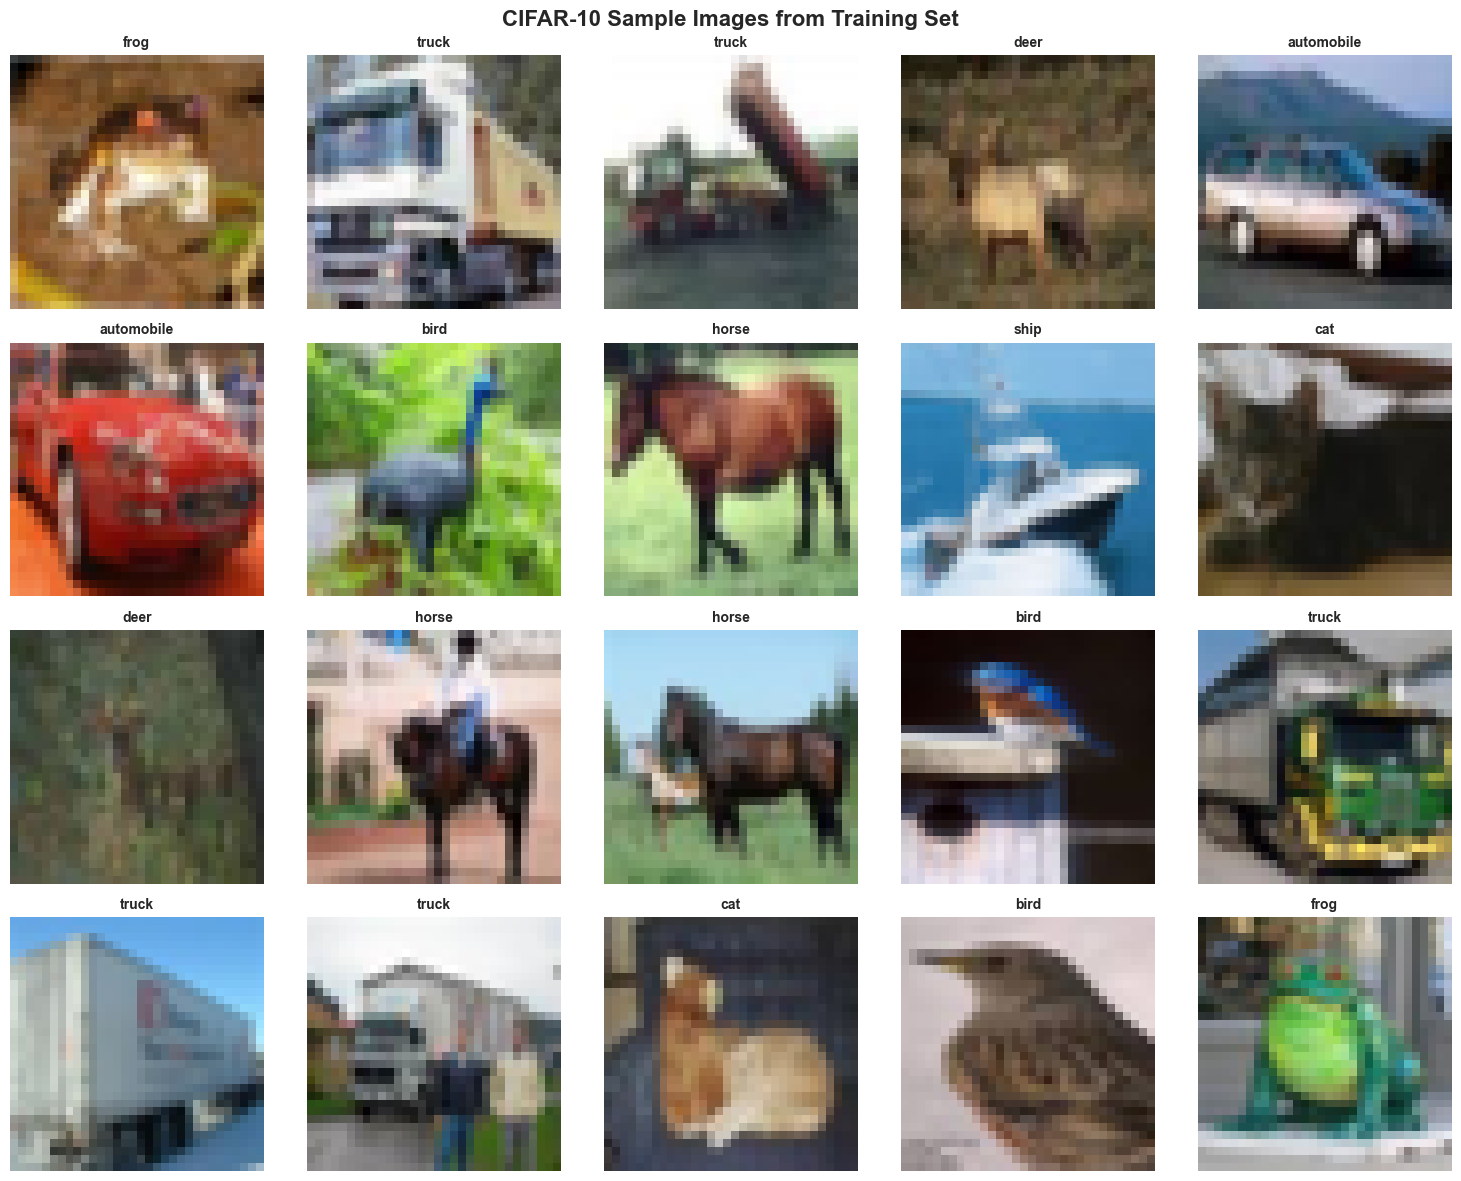

In [4]:
def show_images(dataset, num_samples=20, title="Sample Images"):
    """Display a grid of sample images from the dataset."""
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    for idx, ax in enumerate(axes.flat):
        if idx < num_samples:
            img, label = dataset[idx]
            # Convert from (C, H, W) to (H, W, C) for matplotlib
            img = img.permute(1, 2, 0)
            ax.imshow(img)
            ax.set_title(f'{classes[label]}', fontsize=10, fontweight='bold')
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'figures', 'sample_images.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Display sample images
show_images(trainset, num_samples=20, title="CIFAR-10 Sample Images from Training Set")

## 5. Class Distribution Analysis

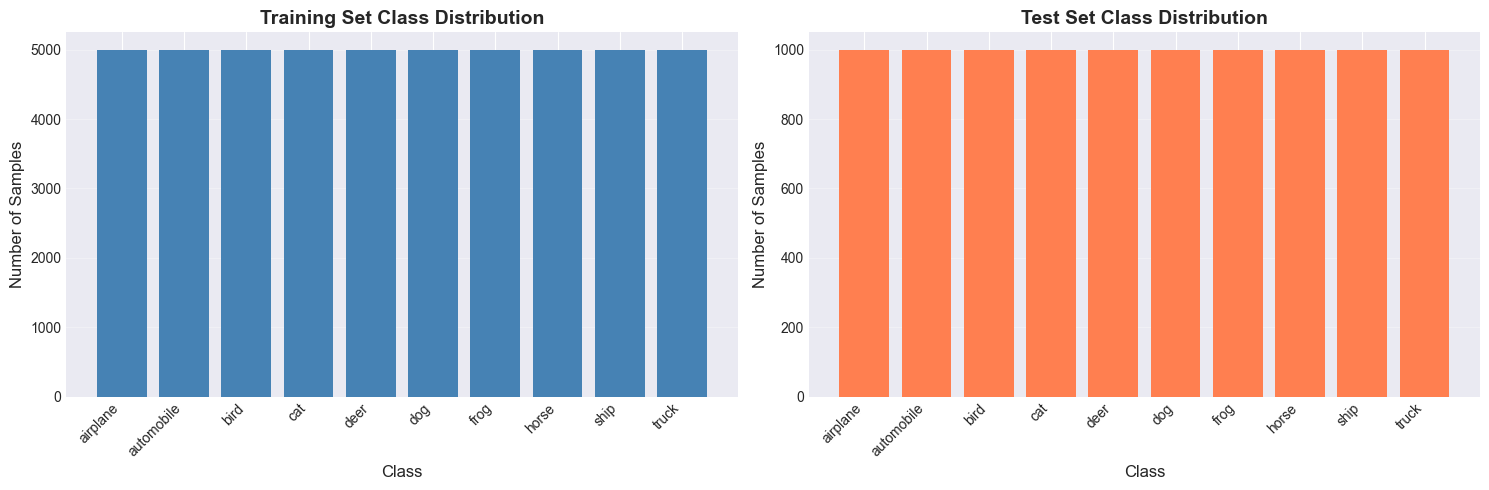


Class Distribution Statistics:

Training Set:
  airplane    :  5000 samples (10.0%)
  automobile  :  5000 samples (10.0%)
  bird        :  5000 samples (10.0%)
  cat         :  5000 samples (10.0%)
  deer        :  5000 samples (10.0%)
  dog         :  5000 samples (10.0%)
  frog        :  5000 samples (10.0%)
  horse       :  5000 samples (10.0%)
  ship        :  5000 samples (10.0%)
  truck       :  5000 samples (10.0%)

Test Set:
  airplane    :  1000 samples (10.0%)
  automobile  :  1000 samples (10.0%)
  bird        :  1000 samples (10.0%)
  cat         :  1000 samples (10.0%)
  deer        :  1000 samples (10.0%)
  dog         :  1000 samples (10.0%)
  frog        :  1000 samples (10.0%)
  horse       :  1000 samples (10.0%)
  ship        :  1000 samples (10.0%)
  truck       :  1000 samples (10.0%)

✅ Dataset is balanced: All classes have equal representation


In [5]:
# Count samples per class
train_labels = [label for _, label in trainset]
test_labels = [label for _, label in testset]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

# Create distribution plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training set distribution
ax1.bar(range(len(classes)), [train_counts[i] for i in range(len(classes))], color='steelblue')
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(classes)))
ax1.set_xticklabels(classes, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Test set distribution
ax2.bar(range(len(classes)), [test_counts[i] for i in range(len(classes))], color='coral')
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Number of Samples', fontsize=12)
ax2.set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(classes)))
ax2.set_xticklabels(classes, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figures', 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("\nClass Distribution Statistics:")
print("\nTraining Set:")
for i, class_name in enumerate(classes):
    print(f"  {class_name:12s}: {train_counts[i]:5d} samples ({train_counts[i]/len(trainset)*100:.1f}%)")

print("\nTest Set:")
for i, class_name in enumerate(classes):
    print(f"  {class_name:12s}: {test_counts[i]:5d} samples ({test_counts[i]/len(testset)*100:.1f}%)")

print(f"\n✅ Dataset is balanced: All classes have equal representation")

## 6. Summary and Key Findings

In [6]:
print("="*70)
print("CIFAR-10 DATASET SUMMARY")
print("="*70)
print(f"\n📊 Dataset Size:")
print(f"   • Training samples: {len(trainset):,}")
print(f"   • Test samples: {len(testset):,}")
print(f"   • Total: {len(trainset) + len(testset):,}")

print(f"\n🖼️  Image Properties:")
print(f"   • Dimensions: 32×32 pixels")
print(f"   • Channels: 3 (RGB)")
print(f"   • Pixel range: [0, 1]")

print(f"\n🏷️  Classes:")
print(f"   • Number of classes: {len(classes)}")
print(f"   • Class names: {', '.join(classes)}")
print(f"   • Distribution: Balanced (5,000 training + 1,000 test per class)")

print(f"\n💡 Key Insights:")
print(f"   1. Dataset is well-balanced across all classes")
print(f"   2. Images are small (32×32), making training faster")
print(f"   3. Low resolution may make some classes challenging to distinguish")
print(f"   4. Data augmentation will be crucial for better generalization")

print(f"\n✅ Dataset exploration complete!")
print(f"   Ready to proceed with model training.")
print("="*70)

CIFAR-10 DATASET SUMMARY

📊 Dataset Size:
   • Training samples: 50,000
   • Test samples: 10,000
   • Total: 60,000

🖼️  Image Properties:
   • Dimensions: 32×32 pixels
   • Channels: 3 (RGB)
   • Pixel range: [0, 1]

🏷️  Classes:
   • Number of classes: 10
   • Class names: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
   • Distribution: Balanced (5,000 training + 1,000 test per class)

💡 Key Insights:
   1. Dataset is well-balanced across all classes
   2. Images are small (32×32), making training faster
   3. Low resolution may make some classes challenging to distinguish
   4. Data augmentation will be crucial for better generalization

✅ Dataset exploration complete!
   Ready to proceed with model training.


## Next Steps

Now that we understand the CIFAR-10 dataset, we can proceed to:

1. **Notebook 02:** Build and train a baseline Custom CNN
2. **Notebook 03:** Implement and train ResNet18
3. **Notebook 04:** Implement and train VGG16
4. **Notebook 05:** Compare all models and analyze results

---

**Key Takeaways:**
- CIFAR-10 is a balanced dataset with 60,000 images across 10 classes
- Images are small (32×32 pixels), which presents both opportunities and challenges
- Visual inspection shows significant intra-class variation

**Ready to build our first CNN model!** 🚀